# Gaussian Process Regression - Artificial Dataset

This notebook is used to
1. Generate some artificial time-series data
1. Train a GP model on that data
1. Analyse the perform of such a model, with plots and so-on

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas import DataFrame

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

## Generating artificial data

We want to generate some artificial data that mimics the general behaviour we'd expect in a time-series. For this simple example, let's just have three main components:
- A linear trend
- A periodic component
- Some Gaussian noise

In [24]:
def generate_dummy_data(
        start: float, end: float, n: int,
        slope: float = 2.0, amp: float = 10.0, freq: float = 2 * np.pi, noise_var: float = 1.0
    ) -> tuple[np.ndarray, np.ndarray]:
    X = np.linspace(start, end, n)

    # Linear component
    trend = slope * X

    # Periodic component
    seasonality = amp * np.sin(freq * X)

    # Add some Gaussian noise
    noise = rng.normal(loc=0.0, scale=np.sqrt(noise_var), size=n)
    
    Y = trend + seasonality + noise
    return (X, Y)

In [27]:
X, y = generate_dummy_data(0, 5, 200)
y_mean = y.mean()
y -= y_mean

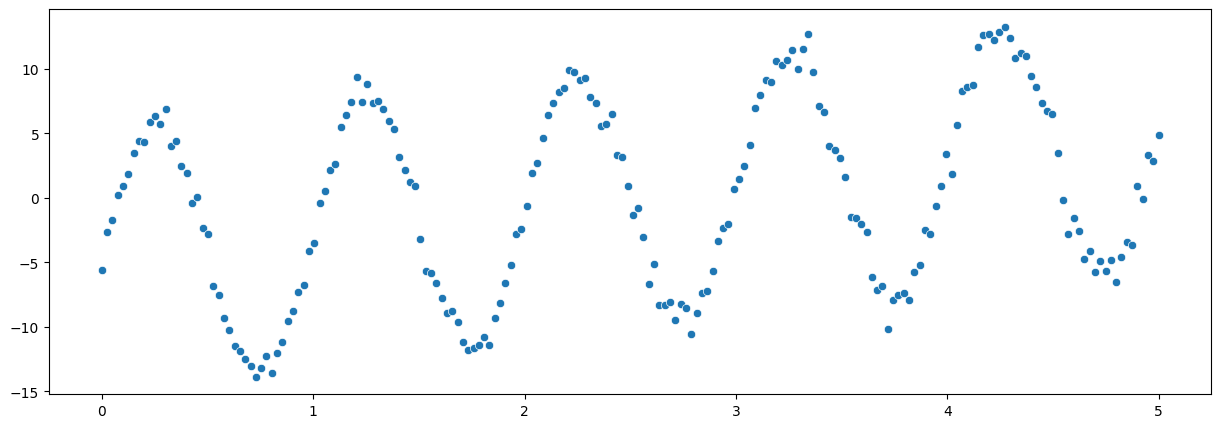

In [30]:
# TODO improve this plot
plt.figure(figsize=(15,5))
sns.scatterplot(x=X, y=y)
plt.show()

## Fitting a GP

The artificial data looks about how we'd expect. Next, we want to fit a GP to this dummy data. To do this, we will create an additive kernel with a component for each part of the dummy data:
- Trend -> rational quadratic -> $l$ and $\alpha$
- Seasonal -> periodic -> $l$ and $p$
- Noise -> white noise -> $\sigma^2$

and each kernel can also have a scale parameter out the front. Hence the summed kernel will be
$$k(x,x') = k_{RQ} + k_{ESS} + k_{WN}$$

In [45]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, RationalQuadratic, ExpSineSquared, WhiteKernel, ConstantKernel

kernel_lin = ConstantKernel(1.0) * RationalQuadratic(3, 1)
kernel_per = ConstantKernel(1.0) * ExpSineSquared(3, 5)
kernel_noi = WhiteKernel(0.5, noise_level_bounds=(1e-5, 1e2))
kernel = kernel_lin + kernel_per + kernel_noi

In [46]:
X = X.reshape(-1, 1)
y = y.reshape(-1, 1) # Remember that we already mean-centered this!

n_restarts = 3
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=n_restarts, random_state=RANDOM_SEED)

In [47]:
gp.fit(X, y)

c:\Users\Angus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=3) + 1**2 * ExpSineSquared(length_scale=3, periodicity=5) + WhiteKernel(noise_level=0.5),
                         n_restarts_optimizer=3, random_state=0)

In [48]:
gp.kernel_

14.6**2 * RationalQuadratic(alpha=1e+05, length_scale=0.356) + 0.291**2 * ExpSineSquared(length_scale=0.00118, periodicity=1.43) + WhiteKernel(noise_level=0.681)

## Analysing model fit

So the GP is now fit. Some fiddling might've been necessary to get a well-behaved kernel optimisation, and will depend on what parameters we set for the dummy data (if we happen to change that). With this done, we can move onto the crux which is visualising and explaining what magic the model is doing.

TODO generic GP visualisation function\
TODO individual kernel visualisations\
TODO nice kernel-to-string for parameter extraction and interpretation

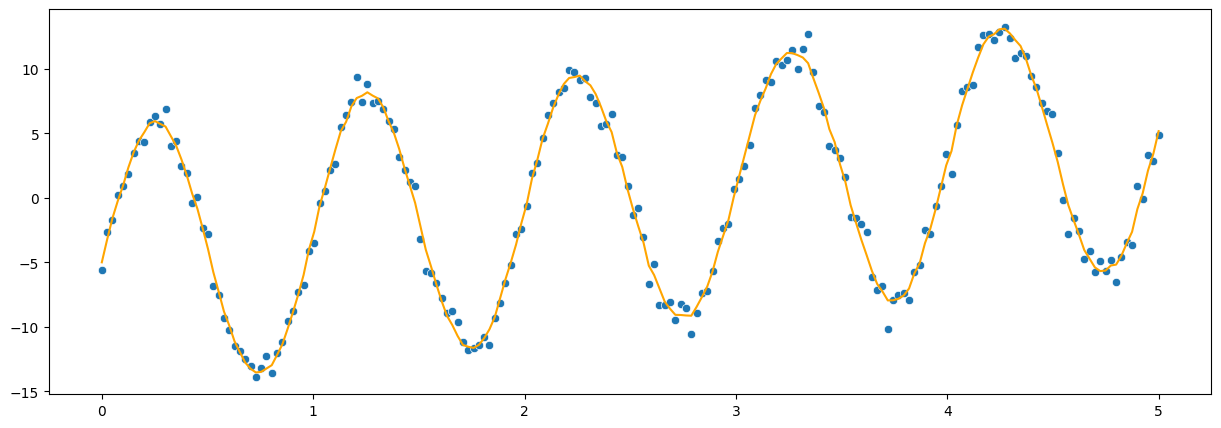

In [51]:
y_pred, std = gp.predict(X, return_std=True)

plt.figure(figsize=(15,5))
sns.scatterplot(x=X.ravel(), y=y.ravel())
sns.lineplot(x=X.ravel(), y=y_pred.ravel(), c="orange")
plt.show()